# Load Data

In [20]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

In [21]:
print(X.shape)  # should be (569, 30)
print(y.shape)
print("Classes:", set(y))

(569, 30)
(569,)
Classes: {np.int64(0), np.int64(1)}


## Standardize

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

## Conver to tensors

In [23]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)

# CVAE

In [24]:
# models/cvae.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class CVAE(nn.Module):
    """
    Conditional VAE for tabular features.

    Encoder: [x, c] -> (mu, logvar)
    Reparam: z = mu + exp(0.5*logvar) * eps
    Decoder: [z, c] -> x_hat
    """
    def __init__(self, x_dim: int, c_dim: int, z_dim: int, hidden: int):
        super().__init__()
        self.x_dim = x_dim
        self.c_dim = c_dim
        self.z_dim = z_dim

        # Encoder
        self.enc = nn.Sequential(
            nn.Linear(x_dim + c_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden, z_dim)
        self.logvar = nn.Linear(hidden, z_dim)

        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(z_dim + c_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, x_dim),  # linear output for MSE/Gaussian recon
        )

    def encode(self, x: torch.Tensor, c: torch.Tensor):
        xc = torch.cat([x, c], dim=1)
        h = self.enc(xc)
        return self.mu(h), self.logvar(h)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor):
        eps = torch.randn_like(mu)
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * eps

    def decode(self, z: torch.Tensor, c: torch.Tensor):
        zc = torch.cat([z, c], dim=1)
        return self.dec(zc)

    def forward(self, x: torch.Tensor, c: torch.Tensor):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z, c)
        return x_hat, mu, logvar
    
if __name__ == "__main__":
    # Quick test
    x_dim, c_dim, z_dim, hidden = 10, 2, 4, 16
    model = CVAE(x_dim, c_dim, z_dim, hidden)
    x = torch.randn(5, x_dim)
    c = F.one_hot(torch.randint(0, c_dim, (5,)), num_classes=c_dim).float()
    x_hat, mu, logvar = model(x, c)
    print("x_hat shape:", x_hat.shape)
    print("mu shape:", mu.shape)
    print("logvar shape:", logvar.shape)

x_hat shape: torch.Size([5, 10])
mu shape: torch.Size([5, 4])
logvar shape: torch.Size([5, 4])


In [25]:
def elbo_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = ((x - x_hat)**2).sum(dim=1).mean()
    kl = (-0.5 * (1 + logvar - mu**2 - logvar.exp()).sum(dim=1)).mean()
    return recon + beta * kl

In [26]:
from dataclasses import dataclass

@dataclass
class Config:
    seed: int = 42

    # CVAE hyperparameters
    z_dim: int = 16
    hidden: int = 128
    beta: float = 0.5
    epochs: int = 200
    batch_size: int = 64
    lr: float = 1e-3

# Now the stuff that can actually chage

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 1) config
cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

# 2) split + scale (NO log1p for now, keep it simple)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=cfg.batch_size, random_state=cfg.seed, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

# 3) loaders
device = "cuda" if torch.cuda.is_available() else "cpu"

X_tr_t = torch.tensor(X_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=cfg.batch_size,
    shuffle=True
)

# 4) train CVAE
model = CVAE(x_dim=X_tr_s.shape[1], c_dim=2, z_dim=cfg.z_dim, hidden=cfg.hidden).to(device)
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

for epoch in range(cfg.epochs):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        cb = F.one_hot(yb, num_classes=2).float()

        x_hat, mu, logvar = model(xb, cb)
        loss = elbo_loss(xb, x_hat, mu, logvar, beta=cfg.beta)

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * xb.size(0)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | loss={total/len(X_tr_t):.4f}")

# 5) sample synthetic in SCALED space
@torch.no_grad()
def sample_scaled(model, n, y_label, device):
    model.eval()
    z = torch.randn(n, model.z_dim, device=device)
    c = F.one_hot(torch.full((n,), y_label, dtype=torch.long, device=device), num_classes=2).float()
    x_scaled = model.decode(z, c)
    return x_scaled.cpu().numpy()

n0 = int((y_te == 0).sum())
n1 = int((y_te == 1).sum())

X_syn0 = sample_scaled(model, n0, y_label=0, device=device)
X_syn1 = sample_scaled(model, n1, y_label=1, device=device)
X_syn  = np.vstack([X_syn0, X_syn1])
y_syn = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
# 6) distinguishability AUC (proper split)
def distinguishability_auc_proper(X_real, X_syn, seed=0):
    X_all = np.vstack([X_real, X_syn])
    s_all = np.concatenate([np.zeros(len(X_real), dtype=int),
                            np.ones(len(X_syn), dtype=int)])

    Xtr, Xte, str_, ste = train_test_split(
        X_all, s_all, test_size=0.3, random_state=seed, stratify=s_all
    )

    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(Xtr, str_)
    p = rf.predict_proba(Xte)[:, 1]
    auc = roc_auc_score(ste, p)
    return auc

auc = distinguishability_auc_proper(X_te_s, X_syn, seed=0)
sep = max(auc, 1-auc)

print("Distinguishability AUC:", auc)
print("Separability:", sep)
print("Target: separability close to 0.5")

Epoch  50 | loss=8.2721
Epoch 100 | loss=7.2485
Epoch 150 | loss=6.7825
Epoch 200 | loss=6.7753
Distinguishability AUC: 0.5144736842105263
Separability: 0.5144736842105263
Target: separability close to 0.5


RF AUC: 0.5144736842105263 RF separability: 0.5144736842105263
Flattened AUC: 0.4900029839409722 Flattened separability: 0.5099970160590278
Top 5 feature separabilities: [0.55615234 0.54760742 0.54711914 0.54711914 0.546875  ]


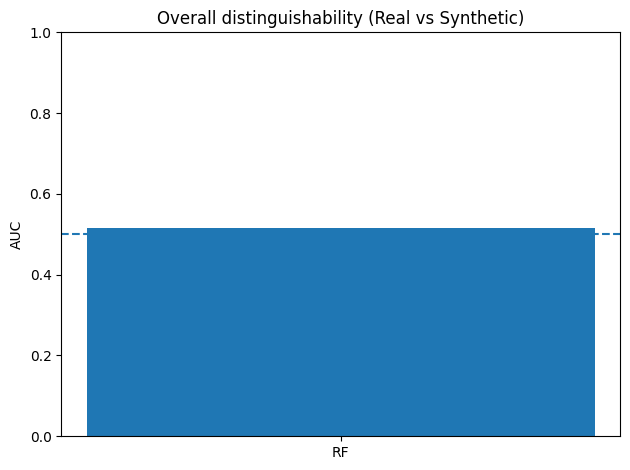

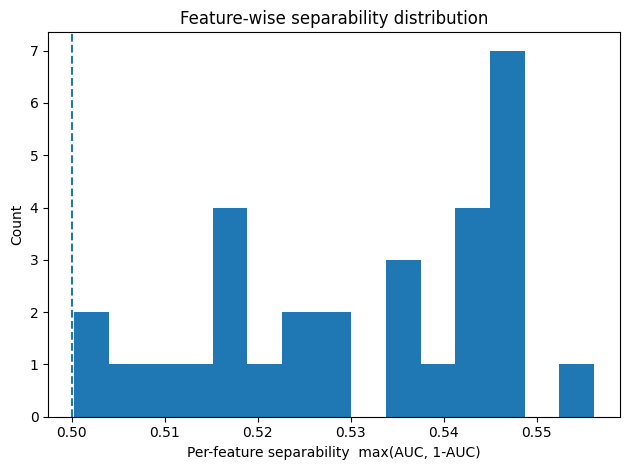

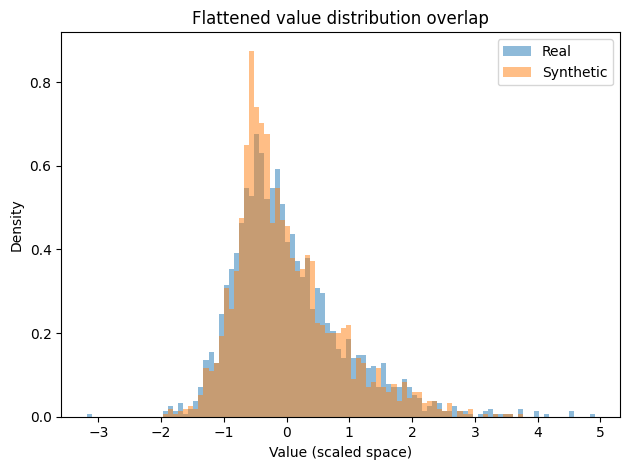

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ---------- helpers ----------
def rf_distinguish_auc_proper(X_real, X_syn, seed=0):
    X_all = np.vstack([X_real, X_syn])
    s_all = np.concatenate([
        np.zeros(len(X_real), dtype=int),
        np.ones(len(X_syn), dtype=int),
    ])

    Xtr, Xte, str_, ste = train_test_split(
        X_all, s_all, test_size=0.3, random_state=seed, stratify=s_all
    )
    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(Xtr, str_)
    # ensure correct proba column for class 1
    pos_idx = int(np.where(rf.classes_ == 1)[0][0])
    p = rf.predict_proba(Xte)[:, pos_idx]
    return roc_auc_score(ste, p)

def flattened_auc(X_real, X_syn, m=200_000, seed=0):
    rng = np.random.default_rng(seed)
    a = X_real.ravel()
    b = X_syn.ravel()
    m = min(m, len(a), len(b))
    a_s = rng.choice(a, size=m, replace=False)
    b_s = rng.choice(b, size=m, replace=False)
    x = np.concatenate([a_s, b_s])
    y = np.concatenate([np.zeros(m), np.ones(m)])
    auc = roc_auc_score(y, x)
    return auc, max(auc, 1 - auc)

def per_feature_separability(X_real, X_syn):
    p = X_real.shape[1]
    seps = np.zeros(p, dtype=float)
    for j in range(p):
        x = np.concatenate([X_real[:, j], X_syn[:, j]])
        y = np.concatenate([np.zeros(len(X_real)), np.ones(len(X_syn))])
        auc = roc_auc_score(y, x)
        seps[j] = max(auc, 1 - auc)
    return seps

# ---------- compute metrics ----------
auc_rf = rf_distinguish_auc_proper(X_te_s, X_syn, seed=0)
sep_rf = max(auc_rf, 1 - auc_rf)

auc_flat, sep_flat = flattened_auc(X_te_s, X_syn, m=200_000, seed=0)
seps = per_feature_separability(X_te_s, X_syn)

print("RF AUC:", auc_rf, "RF separability:", sep_rf)
print("Flattened AUC:", auc_flat, "Flattened separability:", sep_flat)
print("Top 5 feature separabilities:", np.sort(seps)[-5:][::-1])

# ---------- (A) overall AUC figure ----------
plt.figure()
plt.bar(["RF"], [auc_rf])
plt.axhline(0.5, linestyle="--")
plt.ylim(0.0, 1.0)
plt.ylabel("AUC")
plt.title("Overall distinguishability (Real vs Synthetic)")
plt.tight_layout()
plt.savefig("baseline_overall_auc.png", dpi=300)

# ---------- (B) per-feature AUC distribution ----------
plt.figure()
plt.hist(seps, bins=15)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Per-feature separability  max(AUC, 1-AUC)")
plt.ylabel("Count")
plt.title("Feature-wise separability distribution")
plt.tight_layout()
plt.savefig("baseline_feature_auc_distribution.png", dpi=300)

# ---------- (C) flattened distribution overlap ----------
real_flat = X_te_s.ravel()
syn_flat  = X_syn.ravel()

# use matched bins so overlay is fair
combined = np.concatenate([real_flat, syn_flat])
bins = np.histogram_bin_edges(combined, bins=100)

plt.figure()
plt.hist(real_flat, bins=bins, density=True, alpha=0.5, label="Real")
plt.hist(syn_flat,  bins=bins, density=True, alpha=0.5, label="Synthetic")
plt.title("Flattened value distribution overlap")
plt.xlabel("Value (scaled space)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_flattened_overlap.png", dpi=300)

plt.show()

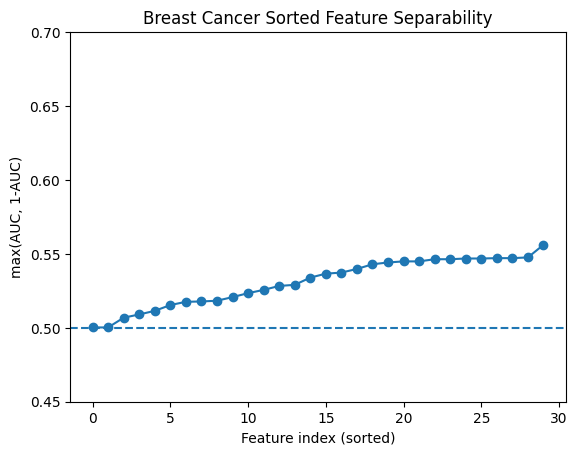

In [29]:
seps_sorted = np.sort(seps)

plt.figure()
plt.plot(seps_sorted, marker='o')
plt.axhline(0.5, linestyle='--')
plt.ylim(0.45, 0.7)
plt.title("Breast Cancer Sorted Feature Separability")
plt.ylabel("max(AUC, 1-AUC)")
plt.xlabel("Feature index (sorted)")
plt.show()

In [30]:
print("Mean sep:", seps.mean())
print("Max sep:", seps.max())
print("Min sep:", seps.min())

Mean sep: 0.5311116536458333
Max sep: 0.55615234375
Min sep: 0.500244140625


# Per feature sep

In [31]:
from sklearn.metrics import roc_auc_score
import numpy as np

def per_feature_sep(X_real, X_syn):
    p = X_real.shape[1]
    seps = []
    for j in range(p):
        x = np.concatenate([X_real[:, j], X_syn[:, j]])
        y = np.concatenate([
            np.zeros(len(X_real)),
            np.ones(len(X_syn))
        ])
        auc = roc_auc_score(y, x)
        sep = max(auc, 1 - auc)
        seps.append((j, sep))
    seps.sort(key=lambda t: t[1], reverse=True)
    return seps

seps = per_feature_sep(X_te_s, X_syn)

print("Top 5 features (breast cancer baseline):")
print(seps[:5])

Top 5 features (breast cancer baseline):
[(13, 0.55615234375), (2, 0.547607421875), (0, 0.547119140625), (3, 0.547119140625), (12, 0.546875)]


In [32]:
import matplotlib.pyplot as plt

def violin_top_features(X_real, X_syn, feature_names, top_idx, k=6):
    top_idx = [j for j, _ in top_idx[:k]]

    fig, axes = plt.subplots(k, 1, figsize=(6, 1.8*k))

    if k == 1:
        axes = [axes]

    for ax, j in zip(axes, top_idx):
        real = X_real[:, j]
        syn  = X_syn[:, j]

        parts = ax.violinplot([real, syn],
                              positions=[1, 2],
                              widths=0.8,
                              showmedians=True,
                              showextrema=False)
        med_diff = np.median(real) - np.median(syn)
       
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Real", "Synthetic"])
        # ax.set_title(feature_names[j], fontsize=9)
        ax.set_title(f"{feature_names[j]}  (Δmed = {med_diff:.2f})")
    plt.tight_layout()
    plt.show()

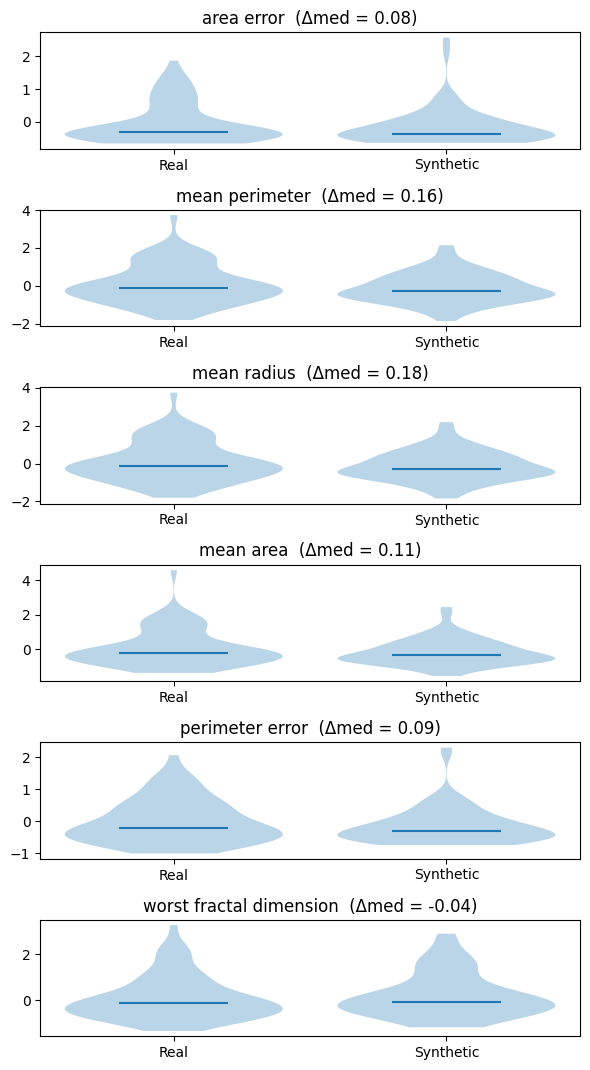

In [33]:
feature_names = data.feature_names  # from sklearn load_breast_cancer

violin_top_features(
    X_real=X_te_s,
    X_syn=X_syn,
    feature_names=feature_names,
    top_idx=seps,
    k=6
)

# Mimicing the conditions of HIV
We want to eliminate the possibility of our high AUC is an artifact of our sampling protocols
- 3/12 hold out.

### Stratify Sampling

In [34]:
import numpy as np

def strat_samp(idx0, idx1, n0, n1, rng):
    a = rng.choice(idx0, size=n0, replace=False)
    b = rng.choice(idx1, size=n1, replace=False)
    return np.concatenate([a, b])

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def one_stochastic_experiment(
    X_real, y_real,
    X_syn,  y_syn,
    holdout0=3, holdout1=12,
    train0=20,  train1=20,
    seed=0
):
    rng = np.random.default_rng(seed)

    real0 = np.where(y_real == 0)[0]
    real1 = np.where(y_real == 1)[0]
    syn0  = np.where(y_syn  == 0)[0]
    syn1  = np.where(y_syn  == 1)[0]

    # holdout indices (stratified, separately in each domain)
    test_real_idx = strat_samp(real0, real1, holdout0, holdout1, rng)
    test_syn_idx  = strat_samp(syn0,  syn1,  holdout0, holdout1, rng)

    # remaining pools for training
    rem_real = np.setdiff1d(np.arange(len(X_real)), test_real_idx)
    rem_syn  = np.setdiff1d(np.arange(len(X_syn)),  test_syn_idx)

    rem_real0 = rem_real[y_real[rem_real] == 0]
    rem_real1 = rem_real[y_real[rem_real] == 1]
    rem_syn0  = rem_syn[y_syn[rem_syn] == 0]
    rem_syn1  = rem_syn[y_syn[rem_syn] == 1]

    train_real_idx = strat_samp(rem_real0, rem_real1, train0, train1, rng)
    train_syn_idx  = strat_samp(rem_syn0,  rem_syn1,  train0, train1, rng)

    # domain classification dataset (s = 0 real, s = 1 synthetic)
    X_train = np.vstack([X_real[train_real_idx], X_syn[train_syn_idx]])
    s_train = np.concatenate([np.zeros(len(train_real_idx), dtype=int),
                              np.ones(len(train_syn_idx), dtype=int)])

    X_test  = np.vstack([X_real[test_real_idx],  X_syn[test_syn_idx]])
    s_test  = np.concatenate([np.zeros(len(test_real_idx), dtype=int),
                              np.ones(len(test_syn_idx), dtype=int)])

    rf = RandomForestClassifier(n_estimators=500, random_state=seed)
    rf.fit(X_train, s_train)
    p = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(s_test, p)

    return auc

# Trails with holdouts

In [42]:
def run_many_trials(X_real, y_real, X_syn, y_syn, trials=200):
    aucs = []
    for t in range(trials):
        aucs.append(one_stochastic_experiment(
            X_real, y_real, X_syn, y_syn,
            holdout0=3, holdout1=12,
            train0=20,  train1=20,
            seed=t
        ))
    aucs = np.array(aucs)
    return aucs

aucs = run_many_trials(X_te_s, y_te, X_syn, y_syn, trials=200)
print("mean AUC:", aucs.mean())
print("std AUC :", aucs.std())
print("min/max :", aucs.min(), aucs.max())

mean AUC: 0.5866777777777779
std AUC : 0.09748934667977513
min/max : 0.3155555555555556 0.8133333333333334


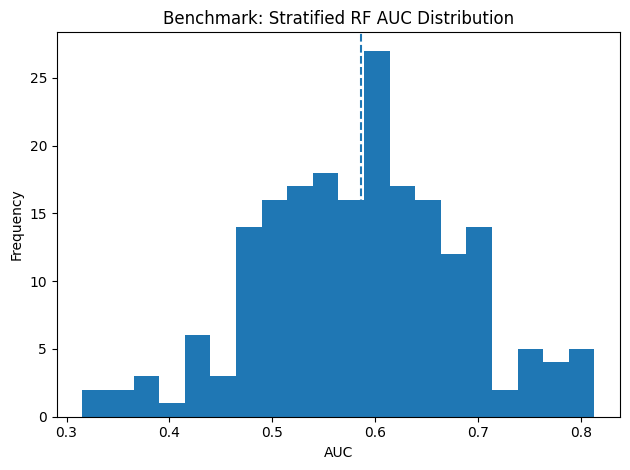

In [43]:
plt.hist(aucs, bins=20)
plt.axvline(aucs.mean(), linestyle='--')
plt.title("Benchmark: Stratified RF AUC Distribution")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("baseline_stratified_auc_hist.png", dpi=300)
plt.show()